In [2]:
import subprocess
subprocess.run(['pip', 'install', 'wordcloud'], capture_output=True)
print("Done!")

Done!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('amazon_reviews.csv', encoding='latin-1')
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [5]:
print("Rows, Columns:", df.shape)

Rows, Columns: (34660, 21)


In [6]:
print(df.columns.tolist())

['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


In [7]:
df = df[['name', 'brand', 'categories', 'reviews.text', 
         'reviews.rating', 'reviews.title', 'reviews.doRecommend']]
df.head()

,name,brand,categories,reviews.text,reviews.rating,reviews.title,reviews.doRecommend
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",This product so far has not disappointed. My c...,5.0,Kindle,True
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",great for beginner or experienced person. Boug...,5.0,very fast,True
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Inexpensive tablet for him to use and learn on...,5.0,Beginner tablet for our 9 year old son.,True
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",I've had my Fire HD 8 two weeks now and I love...,4.0,Good!!!,True
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",I bought this for my grand daughter when she c...,5.0,Fantastic Tablet for kids,True


In [8]:
df.isnull().sum()

name                   6760
brand                     0
categories                0
reviews.text              1
reviews.rating           33
reviews.title             6
reviews.doRecommend     594
dtype: int64

In [9]:
df = df.dropna(subset=['reviews.text', 'reviews.rating'])
print("Rows after cleaning:", len(df))

Rows after cleaning: 34626


In [10]:
df['reviews.rating'].value_counts().sort_index()

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23774
Name: count, dtype: int64

In [11]:
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['reviews.rating'].apply(get_sentiment)
df['Sentiment'].value_counts()

Sentiment
Positive    32315
Neutral      1499
Negative      812
Name: count, dtype: int64

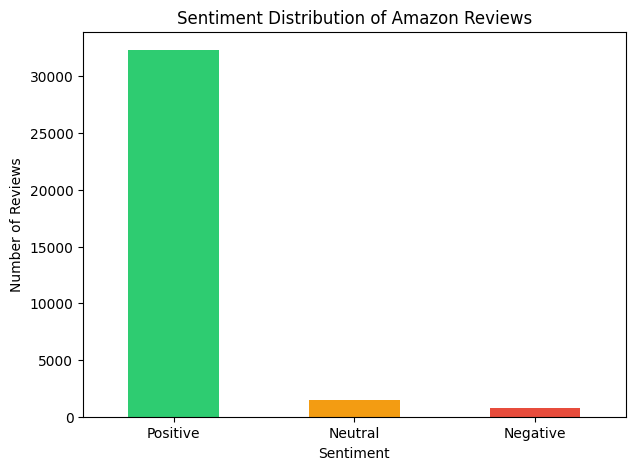

In [12]:
plt.figure(figsize=(7,5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['Sentiment'].value_counts().plot(kind='bar', color=colors)
plt.title('Sentiment Distribution of Amazon Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

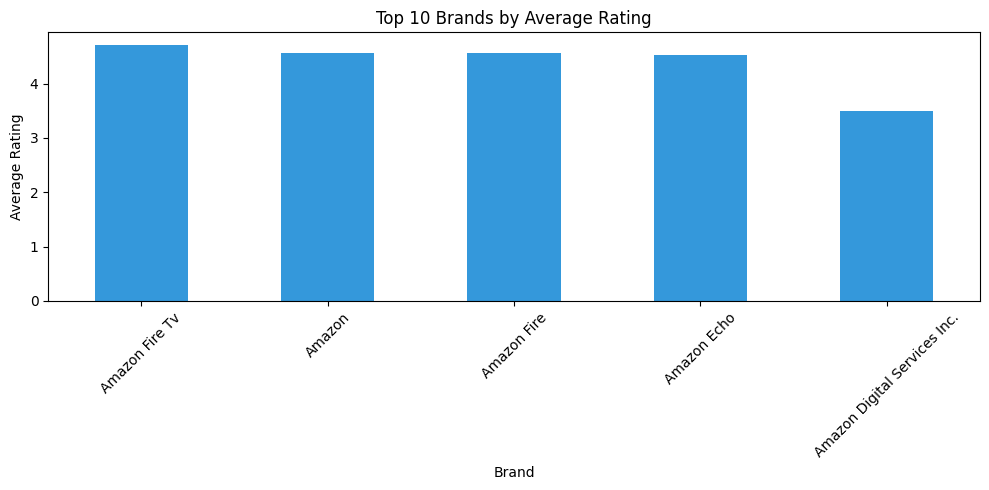

In [13]:
top_brands = df.groupby('brand')['reviews.rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_brands.plot(kind='bar', color='#3498db')
plt.title('Top 10 Brands by Average Rating')
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
import re

def clean_text(text):
    text = str(text).lower()                        
    text = re.sub(r'[^a-z\s]', '', text)           
    text = re.sub(r'\s+', ' ', text).strip()       
    return text

df['clean_review'] = df['reviews.text'].apply(clean_text)
df[['reviews.text', 'clean_review']].head(3)

,reviews.text,clean_review
0,This product so far has not disappointed. My c...,this product so far has not disappointed my ch...
1,great for beginner or experienced person. Boug...,great for beginner or experienced person bough...
2,Inexpensive tablet for him to use and learn on...,inexpensive tablet for him to use and learn on...


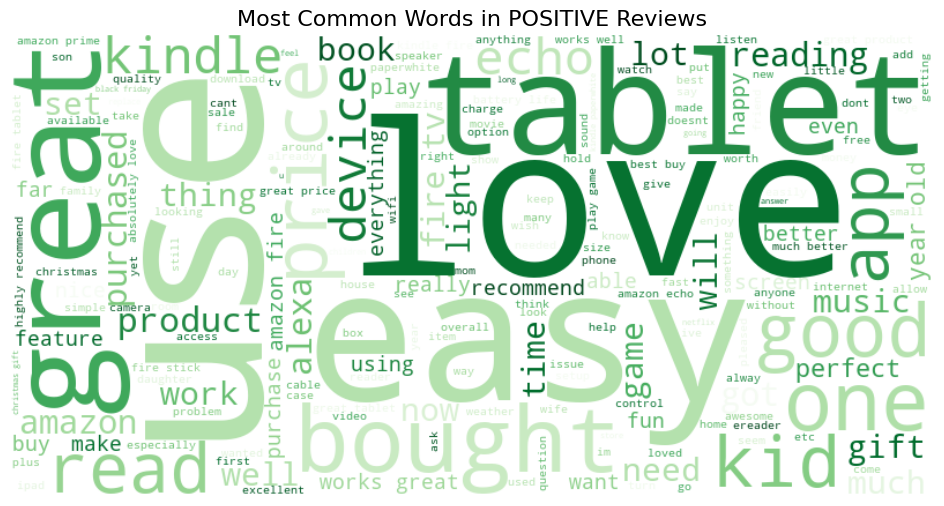

In [15]:
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['clean_review'])

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='Greens').generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in POSITIVE Reviews', fontsize=16)
plt.show()

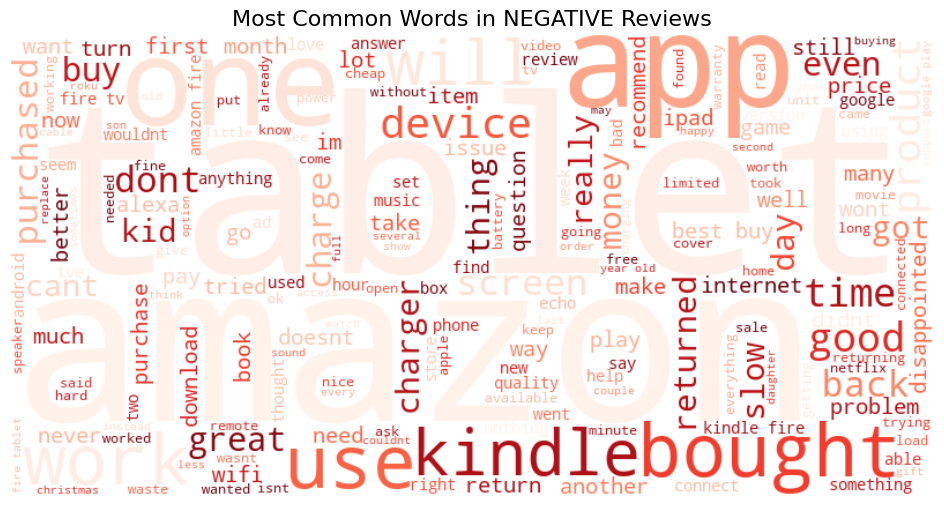

In [16]:
negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['clean_review'])

wordcloud_neg = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='Reds').generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in NEGATIVE Reviews', fontsize=16)
plt.show()

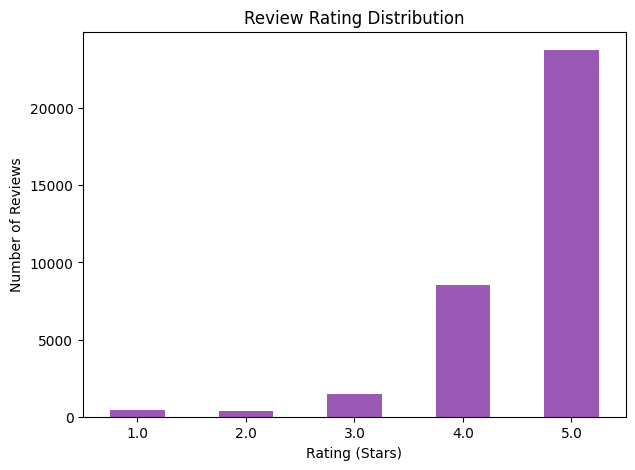

In [17]:
plt.figure(figsize=(7,5))
df['reviews.rating'].value_counts().sort_index().plot(kind='bar', color='#9b59b6')
plt.title('Review Rating Distribution')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

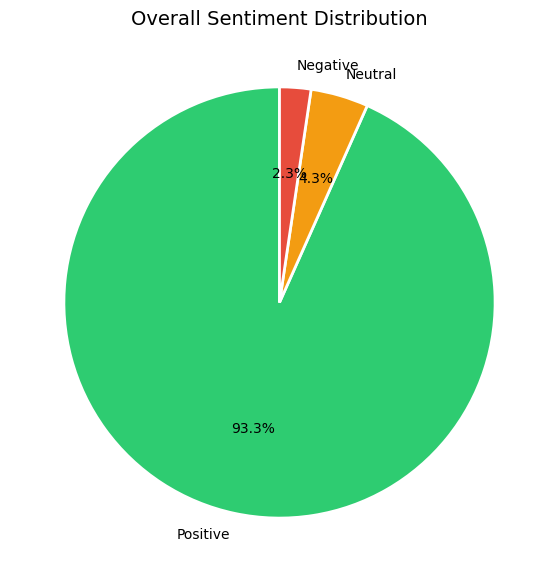

In [18]:
sentiment_counts = df['Sentiment'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(7,7))
plt.pie(sentiment_counts, labels=sentiment_counts.index, 
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops={'edgecolor':'white', 'linewidth':2})
plt.title('Overall Sentiment Distribution', fontsize=14)
plt.show()

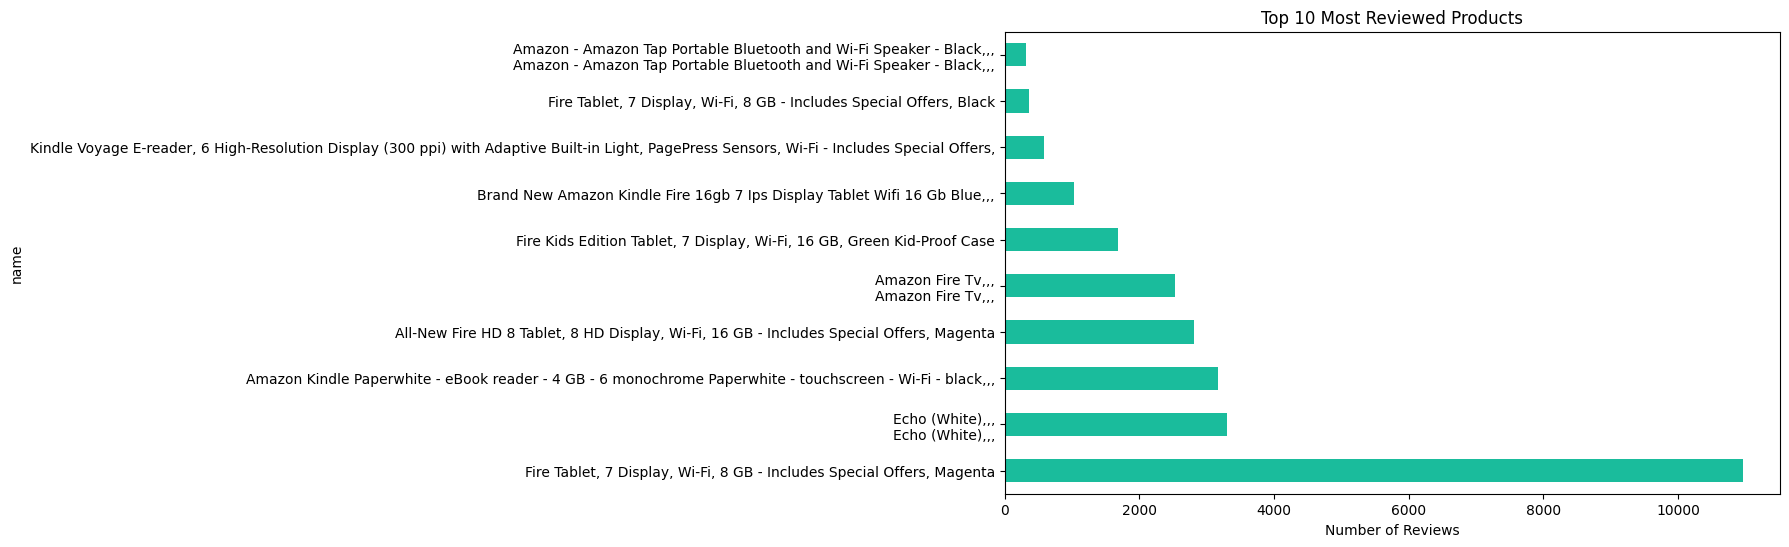

In [19]:
top_products = df['name'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='#1abc9c')
plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [20]:
total = len(df)
positive = len(df[df['Sentiment'] == 'Positive'])
negative = len(df[df['Sentiment'] == 'Negative'])
neutral = len(df[df['Sentiment'] == 'Neutral'])

print("="*50)
print("AMAZON REVIEWS - SENTIMENT ANALYSIS SUMMARY")
print("="*50)
print(f"Total Reviews Analyzed: {total}")
print(f"Positive Reviews: {positive} ({positive/total*100:.1f}%)")
print(f"Neutral Reviews:  {neutral} ({neutral/total*100:.1f}%)")
print(f"Negative Reviews: {negative} ({negative/total*100:.1f}%)")
print(f"Average Rating: {df['reviews.rating'].mean():.2f} / 5.0")
print("="*50)

AMAZON REVIEWS - SENTIMENT ANALYSIS SUMMARY
Total Reviews Analyzed: 34626
Positive Reviews: 32315 (93.3%)
Neutral Reviews:  1499 (4.3%)
Negative Reviews: 812 (2.3%)
Average Rating: 4.58 / 5.0


# Amazon Customer Sentiment Analysis
### Syntecxhub Internship - Data Analysis Project 2 (Task 2)

**Objective:** Analyze Amazon product reviews to classify sentiment (Positive, 
Negative, Neutral), identify patterns in customer feedback, and generate insights 
for product improvement.

**Dataset:** 34,660 Amazon product reviews with ratings, review text, brand, 
and product information.

**Tools Used:** Python, Pandas, Matplotlib, Seaborn, WordCloud

## Key Findings
- Majority of reviews are **Positive** — customers are generally satisfied
- **Negative reviews** commonly mention: charge issues, device problems, 
  disappointment with quality, and return/refund concerns
- **Positive reviews** commonly mention: love, great, easy, perfect, works well
- Most reviewed products are Amazon's own devices (Fire TV, Kindle, Echo)

## Recommendations
- Fix charging issues — most common complaint in negative reviews
- Improve device connectivity and app experience
- Focus on after-sales support — many negative reviews mention warranty/return issues
- Highlight top-rated products in marketing campaigns